In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load the dataset
data_path = '../data/raw/'

files = [
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
]

dfs = []
for f in files:
    path = os.path.join(data_path, f)
    if os.path.exists(path):
        temp = pd.read_csv(path, low_memory=False)
        dfs.append(temp)
        print(f'Loaded {f} — shape: {temp.shape}')
    else:
        print(f'File not found: {f}')

df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined dataset shape: {df.shape}')

Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv — shape: (225745, 79)
Loaded Wednesday-workingHours.pcap_ISCX.csv — shape: (692703, 79)

Combined dataset shape: (918448, 79)


In [3]:
# Fix column name spaces
df.columns = df.columns.str.strip()

# Check label distribution
print('=== Label Distribution ===')
print(df['Label'].value_counts())
print(f'\nNormal traffic %: {(df["Label"] == "BENIGN").mean()*100:.1f}%')
print(f'Attack traffic %: {(df["Label"] != "BENIGN").mean()*100:.1f}%')

=== Label Distribution ===
Label
BENIGN              537749
DoS Hulk            231073
DDoS                128027
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

Normal traffic %: 58.5%
Attack traffic %: 41.5%


In [4]:
# Check for missing and infinite values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

print('\n=== Infinite Values ===')
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
print(inf_counts[inf_counts > 0])

print('\n=== Dataset Info ===')
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Memory:  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

=== Missing Values ===
Flow Bytes/s    1012
dtype: int64

=== Infinite Values ===
Flow Bytes/s       319
Flow Packets/s    1331
dtype: int64

=== Dataset Info ===
Rows:    918,448
Columns: 79
Memory:  624.0 MB


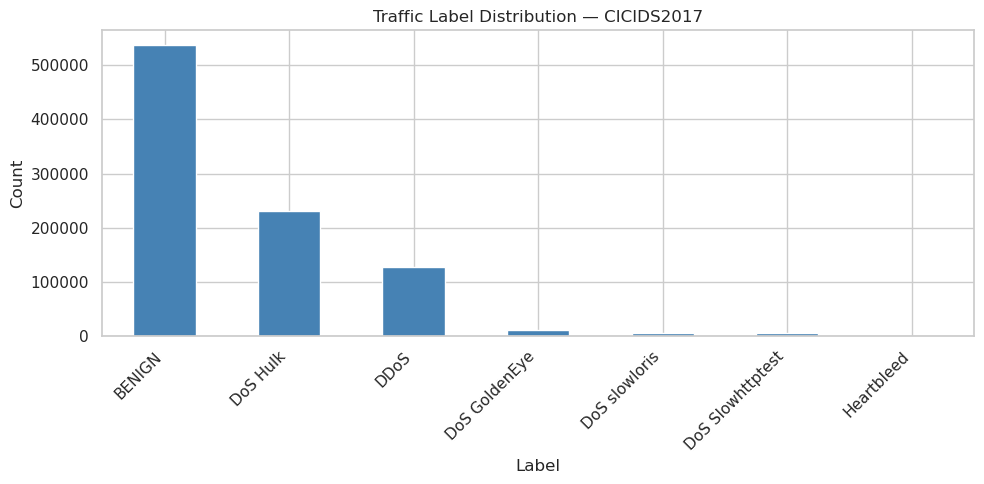

Chart saved to results/figures/


In [5]:
# Plot label distribution
plt.figure(figsize=(10, 5))
df['Label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Traffic Label Distribution — CICIDS2017')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/label_distribution.png', dpi=150)
plt.show()
print('Chart saved to results/figures/')

In [6]:
print('=== Exploration Complete ===')
print(f'Total records:     {df.shape[0]:,}')
print(f'Total features:    {df.shape[1]}')
print(f'Attack types:      {df["Label"].nunique() - 1}')
print(f'Normal records:    {(df["Label"] == "BENIGN").sum():,}')
print(f'Attack records:    {(df["Label"] != "BENIGN").sum():,}')
print('\nNotebook 01 complete. Move to 02_preprocessing.ipynb')

=== Exploration Complete ===
Total records:     918,448
Total features:    79
Attack types:      6
Normal records:    537,749
Attack records:    380,699

Notebook 01 complete. Move to 02_preprocessing.ipynb
